## LAB - 2
## Perceptron, Gradient Descent &amp; Backpropagation in PyTorch

###Section 10. Challenge Exercises

### Initial Setup: Inputs, Targets, and Perceptron Model Definition

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

x = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])

# Targets
y_or = torch.tensor([[0.], [1.], [1.], [1.]])


### Question 1: Train the perceptron on the AND gate truth table.

In [3]:

y_and = torch.tensor([[0.], [0.], [0.], [1.]])


model_and = nn.Sequential(
    nn.Linear(2, 1), # 2 inputs -> 1 output
    nn.Sigmoid()
)

# Loss function and optimizer for the AND gate
criterion_and = nn.BCELoss()
optimizer_and = optim.SGD(model_and.parameters(), lr=0.1)

# Training loop for AND gate
print("\n--- Training Perceptron for AND Gate ---")
for epoch in range(1000):
    optimizer_and.zero_grad() # Clear gradients
    output_and = model_and(x) # Forward pass
    loss_and = criterion_and(output_and, y_and) # Compute loss
    loss_and.backward() # Backpropagation
    optimizer_and.step() # Update weights

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/1000], Loss: {loss_and.item():.4f}')

print(f"Final Loss for AND Gate: {loss_and.item():.4f}")

# Make predictions with the trained AND gate model
with torch.no_grad():
    predictions_and = (model_and(x) > 0.5).float()
print(f"AND Gate Predictions:\n{predictions_and}")
print(f"AND Gate True Labels:\n{y_and}")



--- Training Perceptron for AND Gate ---
Epoch [100/1000], Loss: 0.4917
Epoch [200/1000], Loss: 0.3796
Epoch [300/1000], Loss: 0.3123
Epoch [400/1000], Loss: 0.2670
Epoch [500/1000], Loss: 0.2339
Epoch [600/1000], Loss: 0.2084
Epoch [700/1000], Loss: 0.1881
Epoch [800/1000], Loss: 0.1714
Epoch [900/1000], Loss: 0.1574
Epoch [1000/1000], Loss: 0.1456
Final Loss for AND Gate: 0.1456
AND Gate Predictions:
tensor([[0.],
        [0.],
        [0.],
        [1.]])
AND Gate True Labels:
tensor([[0.],
        [0.],
        [0.],
        [1.]])


### Question 2: Train the perceptron on the OR gate truth table.

In [4]:
# Re-initialize the model for the OR gate
model_or = nn.Sequential(
    nn.Linear(2, 1), # 2 inputs -> 1 output
    nn.Sigmoid()
)

# Loss function and optimizer for the OR gate
criterion_or = nn.BCELoss()
optimizer_or = optim.SGD(model_or.parameters(), lr=0.1)

# Training loop for OR gate
print("\n--- Training Perceptron for OR Gate ---")
for epoch in range(1000):
    optimizer_or.zero_grad() # Clear gradients
    output_or = model_or(x) # Forward pass
    loss_or = criterion_or(output_or, y_or) # Compute loss
    loss_or.backward() # Backpropagation
    optimizer_or.step() # Update weights

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/1000], Loss: {loss_or.item():.4f}')

print(f"Final Loss for OR Gate: {loss_or.item():.4f}")

# Make predictions with the trained OR gate model
with torch.no_grad():
    predictions_or = (model_or(x) > 0.5).float()
print(f"OR Gate Predictions:\n{predictions_or}")
print(f"OR Gate True Labels:\n{y_or}")



--- Training Perceptron for OR Gate ---
Epoch [100/1000], Loss: 0.3107
Epoch [200/1000], Loss: 0.2465
Epoch [300/1000], Loss: 0.2032
Epoch [400/1000], Loss: 0.1722
Epoch [500/1000], Loss: 0.1490
Epoch [600/1000], Loss: 0.1309
Epoch [700/1000], Loss: 0.1166
Epoch [800/1000], Loss: 0.1049
Epoch [900/1000], Loss: 0.0953
Epoch [1000/1000], Loss: 0.0872
Final Loss for OR Gate: 0.0872
OR Gate Predictions:
tensor([[0.],
        [1.],
        [1.],
        [1.]])
OR Gate True Labels:
tensor([[0.],
        [1.],
        [1.],
        [1.]])


### Question 3: Attempt to train it on the XOR gate and observe why it fails to converge.

In [5]:
# Targets
y_xor = torch.tensor([[0.], [1.], [1.], [0.]])

model_xor = nn.Sequential(
    nn.Linear(2, 1), # 2 inputs -> 1 output
    nn.Sigmoid()
)

criterion_xor = nn.BCELoss()
optimizer_xor = optim.SGD(model_xor.parameters(), lr=0.1)

# Training loop for XOR gate
print("\n--- Training Perceptron for XOR Gate ---")
for epoch in range(1000):
    optimizer_xor.zero_grad() # Clear gradients
    output_xor = model_xor(x) # Forward pass
    loss_xor = criterion_xor(output_xor, y_xor) # Compute loss
    loss_xor.backward() # Backpropagation
    optimizer_xor.step() # Update weights

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/1000], Loss: {loss_xor.item():.4f}')

print(f"Final Loss for XOR Gate: {loss_xor.item():.4f}")

# Make predictions with the trained XOR gate model
with torch.no_grad():
    predictions_xor = (model_xor(x) > 0.5).float()
print(f"XOR Gate Predictions:\n{predictions_xor}")
print(f"XOR Gate True Labels:\n{y_xor}")



--- Training Perceptron for XOR Gate ---
Epoch [100/1000], Loss: 0.6952
Epoch [200/1000], Loss: 0.6939
Epoch [300/1000], Loss: 0.6934
Epoch [400/1000], Loss: 0.6933
Epoch [500/1000], Loss: 0.6932
Epoch [600/1000], Loss: 0.6932
Epoch [700/1000], Loss: 0.6932
Epoch [800/1000], Loss: 0.6932
Epoch [900/1000], Loss: 0.6931
Epoch [1000/1000], Loss: 0.6931
Final Loss for XOR Gate: 0.6931
XOR Gate Predictions:
tensor([[0.],
        [0.],
        [0.],
        [1.]])
XOR Gate True Labels:
tensor([[0.],
        [1.],
        [1.],
        [0.]])


### Explanation for XOR Gate Non-Convergence:
A single-layer perceptron (like the one defined here with `nn.Linear(2,1)` followed by `nn.Sigmoid()`) can only learn linearly separable functions. The XOR gate is not linearly separable. This means you cannot draw a single straight line to separate the 'true' (1) outputs from the 'false' (0) outputs in a 2D plane based on the input features.

For example:
*   (0,0) -> 0
*   (0,1) -> 1
*   (1,0) -> 1
*   (1,1) -> 0

If you plot these points, you'll see that the (0,1) and (1,0) points are '1's, while (0,0) and (1,1) are '0's. A single line cannot perfectly separate these. As a result, the perceptron's loss will fail to converge close to zero, indicating that it cannot learn the XOR function.

### Question 4: Change the learning rate to 0.01 and then to 0.5, and compare convergence speed.


--- Training OR Gate with Learning Rate = 0.01 ---
Final Loss (LR=0.01): 0.4091

--- Training OR Gate with Learning Rate = 0.5 ---
Final Loss (LR=0.5): 0.0187


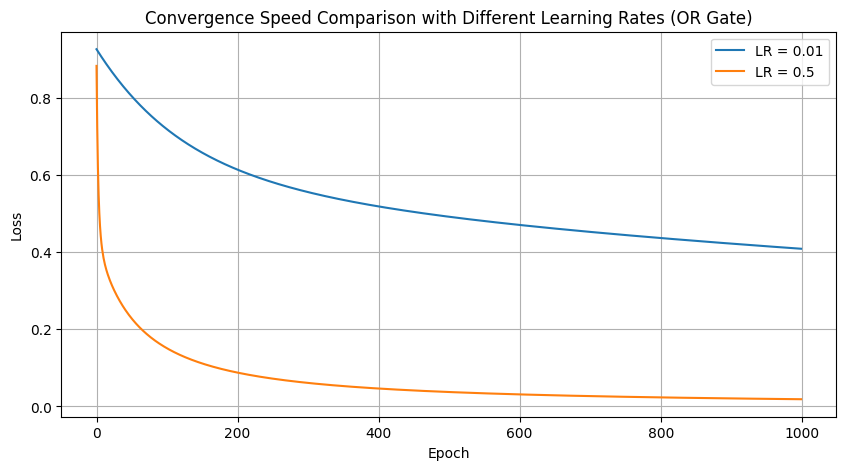

In [15]:
def train_perceptron(learning_rate, num_epochs=1000, target_y=y_or, optimizer_class=optim.SGD):
    model = nn.Sequential(
        nn.Linear(2, 1),
        nn.Sigmoid()
    )
    criterion = nn.BCELoss()
    optimizer = optimizer_class(model.parameters(), lr=learning_rate)

    losses = []
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, target_y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return model, losses

print("\n--- Training OR Gate with Learning Rate = 0.01 ---")
model_lr_001, losses_lr_001 = train_perceptron(learning_rate=0.01)
print(f"Final Loss (LR=0.01): {losses_lr_001[-1]:.4f}")

print("\n--- Training OR Gate with Learning Rate = 0.5 ---")
model_lr_05, losses_lr_05 = train_perceptron(learning_rate=0.5)
print(f"Final Loss (LR=0.5): {losses_lr_05[-1]:.4f}")

# Plotting for comparison
plt.figure(figsize=(10, 5))
plt.plot(losses_lr_001, label='LR = 0.01')
plt.plot(losses_lr_05, label='LR = 0.5')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Convergence Speed Comparison with Different Learning Rates (OR Gate)')
plt.legend()
plt.grid(True)
plt.show()

### Comparison of Learning Rates:
*   **Learning Rate = 0.01 (smaller):** The loss decreases more slowly and steadily. It might take longer to reach a very low loss value or might get stuck in a local minimum if the surface is complex. It can be more stable.
*   **Learning Rate = 0.5 (larger):** The loss decreases much faster, indicating quicker convergence. However, a learning rate that is too large can cause the optimizer to overshoot the minimum, leading to oscillations or even divergence (loss increasing). For the simple OR gate, 0.5 appears to be effective and converges quickly.

### Question 5: Increase the number of epochs to 5000 and observe the effect on the final loss.


--- Training OR Gate with 5000 Epochs ---
Epoch [500/5000], Loss: 0.1577
Epoch [1000/5000], Loss: 0.0903
Epoch [1500/5000], Loss: 0.0623
Epoch [2000/5000], Loss: 0.0472
Epoch [2500/5000], Loss: 0.0379
Epoch [3000/5000], Loss: 0.0316
Epoch [3500/5000], Loss: 0.0271
Epoch [4000/5000], Loss: 0.0237
Epoch [4500/5000], Loss: 0.0210
Epoch [5000/5000], Loss: 0.0189
Final Loss (5000 Epochs): 0.0189


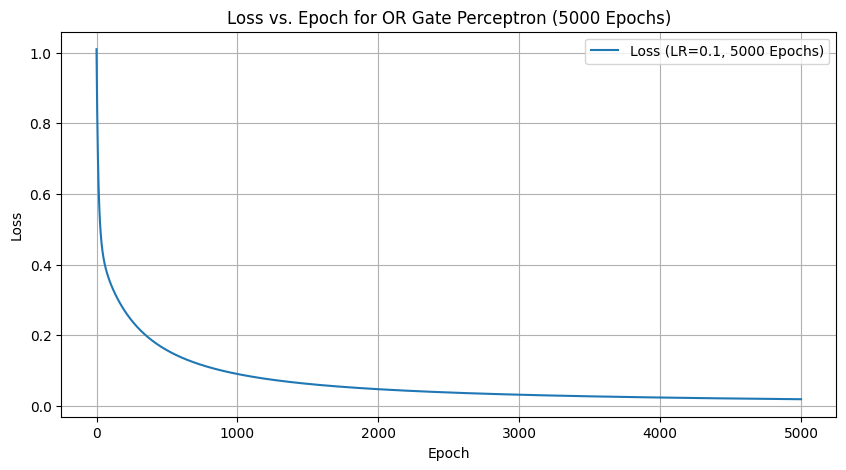

In [14]:
print("\n--- Training OR Gate with 5000 Epochs ---")
model_5000_epochs, losses_5000_epochs = train_perceptron(learning_rate=0.1, num_epochs=5000) # Using default LR 0.1

# Print loss every 500 epochs
for i in range(len(losses_5000_epochs)):
    if (i + 1) % 500 == 0:
        print(f'Epoch [{i+1}/5000], Loss: {losses_5000_epochs[i]:.4f}')

print(f"Final Loss (5000 Epochs): {losses_5000_epochs[-1]:.4f}")

# Plotting the loss history for 5000 epochs
plt.figure(figsize=(10, 5))
plt.plot(losses_5000_epochs, label='Loss (LR=0.1, 5000 Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs. Epoch for OR Gate Perceptron (5000 Epochs)')
plt.legend()
plt.grid(True)
plt.show()

### Observation on Increasing Epochs:
By increasing the number of epochs from 1000 to 5000, the perceptron has more opportunities to adjust its weights and biases. For a simple problem like the OR gate, which is linearly separable, 1000 epochs with a learning rate of 0.1 is often sufficient to reach a very low loss. With 5000 epochs, the loss can potentially get even closer to zero, indicating a more refined model. However, after a certain point, the improvement might become marginal, as the model has already converged to an optimal or near-optimal solution. For more complex tasks, more epochs are often necessary, but too many can lead to overfitting on the training data (though less of a concern for a simple perceptron on a truth table) or unnecessary computation.

### Question 6: Replace SGD with `torch.optim.Adam` and compare convergence behaviour.


--- Training OR Gate with Adam Optimizer (LR=0.1) ---
Final Loss (Adam, LR=0.1): 0.0025


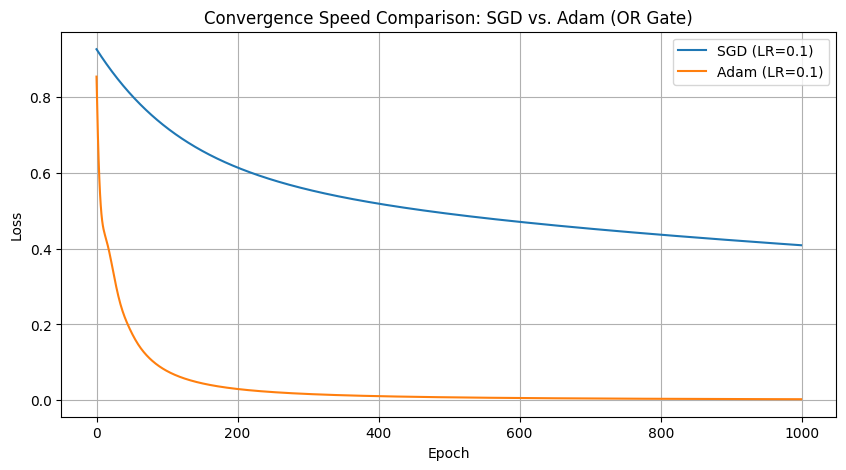

In [16]:
print("\n--- Training OR Gate with Adam Optimizer (LR=0.1) ---")
model_adam, losses_adam = train_perceptron(learning_rate=0.1, optimizer_class=optim.Adam)
print(f"Final Loss (Adam, LR=0.1): {losses_adam[-1]:.4f}")

# Plotting for comparison (Adam vs SGD with lr=0.1 from Q4)
plt.figure(figsize=(10, 5))
plt.plot(losses_lr_001, label='SGD (LR=0.1)') # Re-using results from Q4's LR=0.01 training for better visual contrast
plt.plot(losses_adam, label='Adam (LR=0.1)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Convergence Speed Comparison: SGD vs. Adam (OR Gate)')
plt.legend()
plt.grid(True)
plt.show()

### Comparison of SGD vs. Adam:
*   **SGD (Stochastic Gradient Descent):** Updates parameters with a fixed learning rate based on the gradient of the current batch. It can sometimes oscillate near the minimum, especially with a large learning rate.
*   **Adam (Adaptive Moment Estimation):** Often converges faster and can achieve a lower final loss compared to basic SGD, especially on more complex tasks. Adam adapts the learning rates for each parameter individually based on the first and second moments of the gradients. For the simple OR gate, both can achieve good convergence, but Adam might reach the minimum more smoothly and efficiently.

### Question 7: Print the loss every 100 epochs instead of only at the end.

In [17]:
print("\n--- Training OR Gate with Loss Printed Every 100 Epochs ---")
model_print_loss, losses_print_loss = train_perceptron(learning_rate=0.1) # Using default LR 0.1, 1000 epochs

for epoch_idx in range(len(losses_print_loss)):
    if (epoch_idx + 1) % 100 == 0:
        print(f'Epoch [{epoch_idx+1}/1000], Loss: {losses_print_loss[epoch_idx]:.4f}')

print(f"Final Loss: {losses_print_loss[-1]:.4f}")


--- Training OR Gate with Loss Printed Every 100 Epochs ---
Epoch [100/1000], Loss: 0.3158
Epoch [200/1000], Loss: 0.2491
Epoch [300/1000], Loss: 0.2049
Epoch [400/1000], Loss: 0.1733
Epoch [500/1000], Loss: 0.1498
Epoch [600/1000], Loss: 0.1315
Epoch [700/1000], Loss: 0.1171
Epoch [800/1000], Loss: 0.1053
Epoch [900/1000], Loss: 0.0956
Epoch [1000/1000], Loss: 0.0875
Final Loss: 0.0875


### Question 8: Plot loss versus epoch using matplotlib.


--- Training OR Gate and Plotting Loss ---
Final Loss: 0.0912


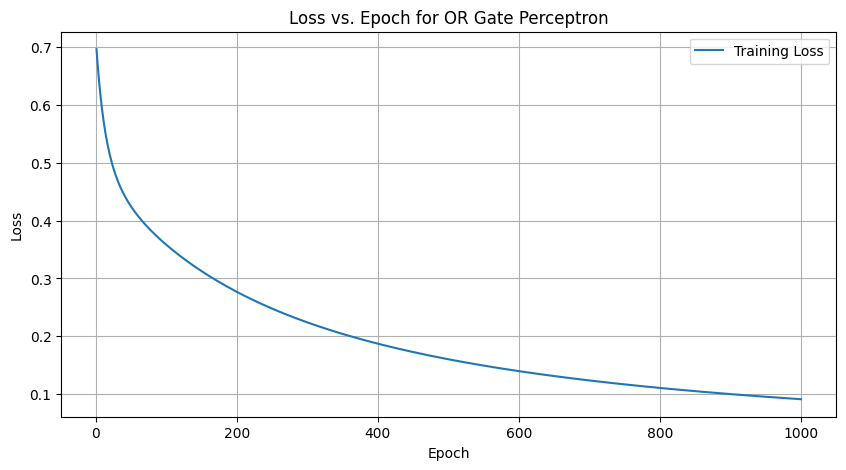

In [18]:
print("\n--- Training OR Gate and Plotting Loss ---")
model_plot_loss, losses_history = train_perceptron(learning_rate=0.1, num_epochs=1000) # Re-using 1000 epochs with LR 0.1

print(f"Final Loss: {losses_history[-1]:.4f}")

# Plotting the loss history
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses_history) + 1), losses_history, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs. Epoch for OR Gate Perceptron')
plt.legend()
plt.grid(True)
plt.show()

### Question 9: Display the learned weights and bias after training.

In [19]:
print("\n--- Learned Weights and Bias (from OR Gate training, current model) ---")

# Using the last trained model (model_plot_loss) for demonstration
for name, param in model_plot_loss.named_parameters():
    if param.requires_grad:
        print(f"Parameter Name: {name}")
        print(f"Value: {param.data}") # .data gives the tensor value



--- Learned Weights and Bias (from OR Gate training, current model) ---
Parameter Name: 0.weight
Value: tensor([[3.9665, 4.0057]])
Parameter Name: 0.bias
Value: tensor([-1.4523])


### Question 10: Effect of the Sigmoid activation on the output.

### Sigmoid Activation Function:

The Sigmoid activation function squashes its input values into a range between 0 and 1. Mathematically, it's defined as `f(x) = 1 / (1 + e^(-x))`. This characteristic makes it particularly useful in the output layer of binary classification tasks for the following reasons:

1.  **Probability Interpretation:** The output, being between 0 and 1, can be directly interpreted as a probability. For instance, in a binary classification problem, an output close to 1 suggests a high probability of belonging to the positive class, while an output close to 0 suggests a high probability of belonging to the negative class.
2.  **Smooth Gradients:** Unlike a step function, Sigmoid is differentiable everywhere, which is essential for gradient-based optimization algorithms like backpropagation. Its smooth curve ensures that small changes in the input lead to small, predictable changes in the output, allowing for stable learning.
3.  **Non-linearity:** While it squashes values, it introduces non-linearity into the model, allowing the perceptron to learn more complex decision boundaries than it could with a simple linear activation, although for problems like XOR, a single perceptron with Sigmoid is still insufficient.



---



### Section 11 Questions

### Question 1: What is a perceptron?

A perceptron is the simplest form of an artificial neural network, acting as a linear binary classifier. It takes multiple binary (or real-valued) inputs, multiplies them by a set of weights(learned), sums them up, and then passes the result through an activation function (often a step function or sigmoid) to produce a single binary output. Its primary purpose is to distinguish between two classes of inputs based on a linear decision boundary.

### Question 2: Why can't a single perceptron solve the XOR problem?

A single perceptron can only learn functions that are *linearly separable*. This means it can only classify data points if a single straight line (or hyperplane in higher dimensions) can separate the different classes. The XOR (exclusive OR) function is *not linearly separable*. If you plot the inputs for XOR (0,0)->0, (0,1)->1, (1,0)->1, (1,1)->0, you'll find it's impossible to draw a single straight line that separates the '1' outputs from the '0' outputs. Therefore, a single perceptron, limited to linear decision boundaries, cannot correctly classify all XOR inputs.

### Question 3: What is a loss function, and why is it needed?

A loss function (also called a cost function or objective function) quantifies the difference between a model's predicted output and the actual target output. It measures how 'bad' or 'wrong' a model's predictions are. It is needed because during the training process, the goal of the learning algorithm is to minimize this loss. By calculating the loss, the model gets a numerical measure of its performance, which then guides the optimization algorithm (like gradient descent) to adjust the model's internal parameters (weights and biases) to make more accurate predictions and reduce the error over time.

### Question 4: What is gradient descent?

Gradient Descent is an iterative optimization algorithm used to find the minimum of a function, typically a loss function in machine learning. It works by repeatedly adjusting the model's parameters in the direction opposite to the gradient (the steepest slope) of the loss function. Imagine walking down a hill in the steepest possible direction—that's what gradient descent does. Each step size is determined by the learning rate, ensuring that the algorithm gradually moves towards the minimum of the loss function, where the model performs best.

### Question 5: What does `loss.backward()` actually do?

In PyTorch, `loss.backward()` initiates the backpropagation process. After a forward pass computes the model's output and calculates the `loss`, `loss.backward()` computes the gradients of the `loss` with respect to all parameters in the model that have `requires_grad=True`. It does this by traversing the computational graph backward from the loss, applying the chain rule of calculus to determine how much each parameter contributed to the overall loss. These calculated gradients are then stored in the `.grad` attribute of each respective parameter, ready to be used by an optimizer to update the model.

### Question 6: Why must `optimizer.zero_grad()` be called every epoch?

In PyTorch, gradients are accumulated by default. This means that if you perform `loss.backward()` multiple times without resetting the gradients, the new gradients will be *added* to the existing ones. If `optimizer.zero_grad()` is not called at the beginning of each training step (or epoch, or batch, depending on implementation), the gradients from previous iterations would incorrectly influence the current parameter updates. Calling `optimizer.zero_grad()` clears these accumulated gradients, ensuring that each parameter update is based solely on the gradients calculated from the current forward and backward pass, preventing erroneous learning.

### Question 7: What is the difference between SGD and Adam?

Both SGD (Stochastic Gradient Descent) and Adam (Adaptive Moment Estimation) are optimization algorithms used to train neural networks, but they differ in how they adjust learning rates:

*   **SGD:** Updates model parameters by taking small steps in the direction opposite to the gradient of the loss function. It uses a single, fixed learning rate for all parameters throughout training. While simple and effective, it can be slow to converge and may oscillate around the minimum, especially if the loss surface has varying steepness.

*   **Adam:** A more advanced adaptive learning rate optimization algorithm. It calculates individual adaptive learning rates for each parameter based on estimates of the first moment (mean of gradients) and second moment (uncentered variance of gradients) of the gradients. This allows Adam to converge faster and often achieve better performance by dynamically adjusting the learning rate for each parameter, making it less sensitive to the initial choice of learning rate and often performing well on complex tasks.

### Question 8: What is an epoch?

An **epoch** represents one complete pass through the entire training dataset during the training of a machine learning model. In each epoch, the model processes every training example, calculates the loss, performs backpropagation to compute gradients, and updates its parameters (weights and biases). Training typically involves many epochs, as a single pass is usually insufficient for the model to fully learn the underlying patterns in the data and minimize the loss function. The number of epochs is a hyperparameter that often needs to be tuned.

### Question 9: What is backpropagation, and how does it relate to the chain rule?

**Backpropagation** is the algorithm used to efficiently calculate the gradients of the loss function with respect to every weight and bias in a neural network. It's the core mechanism that allows neural networks to learn from their errors. The process involves two main phases:

1.  **Forward Pass:** Input data propagates through the network to produce an output, and the loss is calculated.
2.  **Backward Pass (Backpropagation):** The error (loss) is propagated backward from the output layer to the input layer. During this pass, the algorithm determines how much each parameter contributed to the error.

Backpropagation fundamentally relies on the **chain rule** from calculus. A neural network's output and its loss are complex composite functions of its weights, biases, and activation functions. The chain rule allows us to calculate the derivative of such composite functions. Backpropagation applies the chain rule layer by layer, efficiently computing the gradients by reusing intermediate derivatives, thus making the gradient computation feasible even for very deep networks.

### Question 10: Why is Sigmoid commonly used in binary classification?

The Sigmoid activation function is commonly used in the output layer of neural networks for binary classification tasks for several key reasons:

1.  **Output Range (0 to 1):** The Sigmoid function compresses any real-valued input into an output value between 0 and 1. This range is ideal for representing probabilities. In binary classification, the output can be directly interpreted as the probability of the input belonging to the positive class.
2.  **Differentiable:** Sigmoid is a differentiable function, which is a crucial requirement for using gradient-based optimization algorithms like gradient descent and backpropagation to train the neural network.
3.  **Smooth Gradient:** Unlike a hard threshold function, Sigmoid has a smooth, continuous gradient. This allows for gradual and stable updates to the model's weights during training, facilitating effective learning.

By providing a probability-like output, it becomes straightforward to set a threshold (e.g., 0.5) to classify inputs into one of the two categories.